In [1]:
# ============================================================
# Phase H — Similarity Search and Discovery Engine
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd

from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances


# ============================================================
# 1. Paths and folders
# ============================================================

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs"

GRAPH_EMBED_DIR = OUTPUT_DIR / "graph_embeddings"
MOTIF_DIR = OUTPUT_DIR / "motif_discovery"

SIMILARITY_DIR = OUTPUT_DIR / "similarity_search"
FIGURE_DIR = SIMILARITY_DIR / "figures"
QUERY_DIR = SIMILARITY_DIR / "query_results"

SIMILARITY_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
QUERY_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("GRAPH_EMBED_DIR exists:", GRAPH_EMBED_DIR.exists())
print("MOTIF_DIR exists:", MOTIF_DIR.exists())
print("SIMILARITY_DIR:", SIMILARITY_DIR)


# ============================================================
# 2. Locate input files
# ============================================================

embedding_candidates = [
    GRAPH_EMBED_DIR / "embeddings" / "structure_embeddings.csv",
    OUTPUT_DIR / "graph_embeddings" / "embeddings" / "structure_embeddings.csv",
    OUTPUT_DIR / "structure_embeddings.csv",
]

cluster_candidates = [
    MOTIF_DIR / "cluster_assignments_primary.csv",
    MOTIF_DIR / "cluster_assignments_all_methods.csv",
]

embedding_path = next((p for p in embedding_candidates if p.exists()), None)
cluster_path = next((p for p in cluster_candidates if p.exists()), None)

print("embedding_path:", embedding_path)
print("cluster_path:", cluster_path)

assert embedding_path is not None, "Could not find structure_embeddings.csv"
assert cluster_path is not None, "Could not find cluster assignment file"


# ============================================================
# 3. Load data
# ============================================================

emb_df = pd.read_csv(embedding_path)
cluster_df = pd.read_csv(cluster_path)

print("\nLoaded shapes:")
print("emb_df:", emb_df.shape)
print("cluster_df:", cluster_df.shape)

print("\nEmbedding columns:")
print(emb_df.columns.tolist())

print("\nCluster columns:")
print(cluster_df.columns.tolist())


# ============================================================
# 4. Validate schema
# ============================================================

required_emb_cols = [
    "structure_id",
    "relative_cif_path",
    "lower_rotation",
    "displacement",
    "upper_rotation",
    "energy",
    "delta_energy",
]

for col in required_emb_cols:
    assert col in emb_df.columns, f"{col} missing in structure_embeddings.csv"

assert "structure_id" in cluster_df.columns, "structure_id missing in cluster assignment file"

embedding_cols = [c for c in emb_df.columns if c.startswith("emb_")]
assert len(embedding_cols) > 0, "No embedding columns found"

print("\nNumber of embedding columns:", len(embedding_cols))
print("First 10 embedding columns:", embedding_cols[:10])

cluster_label_col = None
for candidate in ["cluster_label", "cluster", "label", "hdbscan_cluster", "primary_cluster"]:
    if candidate in cluster_df.columns:
        cluster_label_col = candidate
        break

assert cluster_label_col is not None, "Could not find cluster label column"
print("Using cluster label column:", cluster_label_col)


# ============================================================
# 5. Keep common structure IDs only
# ============================================================

common_ids = set(emb_df["structure_id"]) & set(cluster_df["structure_id"])
print("\nCommon structure IDs:", len(common_ids))

emb_df = emb_df[emb_df["structure_id"].isin(common_ids)].copy()
cluster_df = cluster_df[cluster_df["structure_id"].isin(common_ids)].copy()

print("Filtered shapes:")
print("emb_df:", emb_df.shape)
print("cluster_df:", cluster_df.shape)


# ============================================================
# 6. Build unified retrieval table
# ============================================================

retrieval_df = emb_df.merge(
    cluster_df[["structure_id", cluster_label_col]],
    on="structure_id",
    how="left",
)

retrieval_df = retrieval_df.rename(columns={cluster_label_col: "cluster_label"})
retrieval_df = retrieval_df.sort_values("structure_id").reset_index(drop=True)

print("\nretrieval_df shape:", retrieval_df.shape)
print(retrieval_df.head())

print("\nMissing values summary:")
print(
    retrieval_df[
        [
            "relative_cif_path",
            "lower_rotation",
            "displacement",
            "upper_rotation",
            "energy",
            "delta_energy",
            "cluster_label",
        ]
    ].isna().sum()
)


# ============================================================
# 7. Prepare embedding matrix
# ============================================================

X = retrieval_df[embedding_cols].to_numpy(dtype=float)
structure_ids = retrieval_df["structure_id"].tolist()

print("\nEmbedding matrix shape:", X.shape)


# ============================================================
# 8. Compute pairwise similarity / distance
# ============================================================

cosine_sim = cosine_similarity(X)
euclid_dist = euclidean_distances(X)

np.fill_diagonal(cosine_sim, -np.inf)
np.fill_diagonal(euclid_dist, np.inf)

print("cosine_sim shape:", cosine_sim.shape)
print("euclid_dist shape:", euclid_dist.shape)


# ============================================================
# 9. Build neighbor tables
# ============================================================

TOP_K = 10
print("\nTOP_K =", TOP_K)


def build_neighbor_table(matrix, ids, metric_name, top_k=10, higher_is_better=True):
    rows = []

    for i, query_id in enumerate(ids):
        scores = matrix[i]

        if higher_is_better:
            neighbor_idx = np.argsort(scores)[::-1][:top_k]
        else:
            neighbor_idx = np.argsort(scores)[:top_k]

        for rank, j in enumerate(neighbor_idx, start=1):
            rows.append(
                {
                    "query_structure_id": query_id,
                    "neighbor_rank": rank,
                    "neighbor_structure_id": ids[j],
                    "metric": metric_name,
                    "score": float(scores[j]),
                }
            )

    return pd.DataFrame(rows)


neighbor_cosine = build_neighbor_table(
    cosine_sim,
    structure_ids,
    metric_name="cosine_similarity",
    top_k=TOP_K,
    higher_is_better=True,
)

neighbor_euclid = build_neighbor_table(
    euclid_dist,
    structure_ids,
    metric_name="euclidean_distance",
    top_k=TOP_K,
    higher_is_better=False,
)

print("neighbor_cosine shape:", neighbor_cosine.shape)
print("neighbor_euclid shape:", neighbor_euclid.shape)


# ============================================================
# 10. Attach neighbor metadata
# ============================================================

neighbor_metadata_cols = [
    "structure_id",
    "cluster_label",
    "energy",
    "delta_energy",
    "lower_rotation",
    "displacement",
    "upper_rotation",
    "relative_cif_path",
]

neighbor_metadata = retrieval_df[neighbor_metadata_cols].rename(
    columns={"structure_id": "neighbor_structure_id"}
)

neighbor_cosine = neighbor_cosine.merge(
    neighbor_metadata,
    on="neighbor_structure_id",
    how="left",
)

neighbor_euclid = neighbor_euclid.merge(
    neighbor_metadata,
    on="neighbor_structure_id",
    how="left",
)

print("\nneighbor_cosine preview:")
print(neighbor_cosine.head())

print("\nneighbor_euclid preview:")
print(neighbor_euclid.head())


# ============================================================
# 11. Save neighbor index files
# ============================================================

cosine_path = SIMILARITY_DIR / "neighbor_index_cosine.csv"
euclid_path = SIMILARITY_DIR / "neighbor_index_euclidean.csv"

neighbor_cosine.to_csv(cosine_path, index=False)
neighbor_euclid.to_csv(euclid_path, index=False)

print("\nSaved:")
print(cosine_path)
print(euclid_path)


# ============================================================
# 12. Query functions
# ============================================================

def get_structure_metadata(structure_id, source_df):
    row = source_df.loc[source_df["structure_id"] == structure_id]
    if row.empty:
        raise ValueError(f"structure_id not found: {structure_id}")
    return row.iloc[0].to_dict()


def get_top_neighbors(query_structure_id, metric_df, k=10):
    result = (
        metric_df.loc[metric_df["query_structure_id"] == query_structure_id]
        .sort_values("neighbor_rank")
        .head(k)
        .reset_index(drop=True)
    )
    return result


def compare_query_and_neighbors(query_structure_id, metric_df, retrieval_source, k=10):
    query_meta = get_structure_metadata(query_structure_id, retrieval_source)
    neighbors = get_top_neighbors(query_structure_id, metric_df, k=k).copy()

    neighbors["query_energy"] = query_meta["energy"]
    neighbors["query_delta_energy"] = query_meta["delta_energy"]
    neighbors["query_cluster_label"] = query_meta["cluster_label"]
    neighbors["query_lower_rotation"] = query_meta["lower_rotation"]
    neighbors["query_displacement"] = query_meta["displacement"]
    neighbors["query_upper_rotation"] = query_meta["upper_rotation"]

    neighbors["same_cluster"] = neighbors["cluster_label"] == query_meta["cluster_label"]
    neighbors["energy_difference"] = neighbors["energy"] - query_meta["energy"]
    neighbors["delta_energy_difference"] = neighbors["delta_energy"] - query_meta["delta_energy"]
    neighbors["lower_rotation_difference"] = neighbors["lower_rotation"] - query_meta["lower_rotation"]
    neighbors["displacement_difference"] = neighbors["displacement"] - query_meta["displacement"]
    neighbors["upper_rotation_difference"] = neighbors["upper_rotation"] - query_meta["upper_rotation"]

    return neighbors


# ============================================================
# 13. Example query results
# ============================================================

sample_query_id = retrieval_df["structure_id"].iloc[0]
print("\nSample query structure_id:", sample_query_id)

sample_neighbors_cosine = get_top_neighbors(sample_query_id, neighbor_cosine, k=10)
sample_neighbors_euclid = get_top_neighbors(sample_query_id, neighbor_euclid, k=10)

print("\nSample cosine neighbors:")
print(sample_neighbors_cosine)

print("\nSample euclidean neighbors:")
print(sample_neighbors_euclid)


# ============================================================
# 14. Build case-study queries
# ============================================================

sorted_low = retrieval_df.sort_values("delta_energy", ascending=True).reset_index(drop=True)
sorted_high = retrieval_df.sort_values("delta_energy", ascending=False).reset_index(drop=True)

query_examples = [
    sorted_low.iloc[0]["structure_id"],
    sorted_low.iloc[len(sorted_low) // 2]["structure_id"],
    sorted_high.iloc[0]["structure_id"],
]

query_examples = list(dict.fromkeys(query_examples))
print("\nQuery examples:", query_examples)

all_query_results = []
for qid in query_examples:
    temp = compare_query_and_neighbors(qid, neighbor_cosine, retrieval_df, k=10).copy()
    temp["query_structure_id"] = qid
    all_query_results.append(temp)

query_case_df = pd.concat(all_query_results, ignore_index=True)

query_case_path = SIMILARITY_DIR / "query_case_studies.csv"
query_case_df.to_csv(query_case_path, index=False)

print("\nSaved:", query_case_path)
print(query_case_df.head(20))


# ============================================================
# 15. Save individual query result files
# ============================================================

for qid in query_examples:
    q_df = compare_query_and_neighbors(qid, neighbor_cosine, retrieval_df, k=10).copy()
    safe_qid = str(qid).replace("/", "_").replace("\\", "_")
    q_path = QUERY_DIR / f"neighbors_{safe_qid}.csv"
    q_df.to_csv(q_path, index=False)
    print("Saved:", q_path)


# ============================================================
# 16. Motif-based retrieval system
# ============================================================

motif_memberships = retrieval_df[
    [
        "structure_id",
        "relative_cif_path",
        "cluster_label",
        "energy",
        "delta_energy",
        "lower_rotation",
        "displacement",
        "upper_rotation",
    ]
].copy()

motif_memberships = motif_memberships.sort_values(
    by=["cluster_label", "delta_energy", "energy"],
    ascending=[True, True, True]
).reset_index(drop=True)

motif_memberships_path = SIMILARITY_DIR / "motif_memberships.csv"
motif_memberships.to_csv(motif_memberships_path, index=False)

print("\nSaved:", motif_memberships_path)


# ============================================================
# 17. Motif representatives
# ============================================================

cluster_centers = (
    retrieval_df.groupby("cluster_label")[embedding_cols]
    .mean()
)

representative_rows = []

for cluster_value, center_vector in cluster_centers.iterrows():
    cluster_subset = retrieval_df[retrieval_df["cluster_label"] == cluster_value].copy()

    if cluster_subset.empty:
        continue

    cluster_X = cluster_subset[embedding_cols].to_numpy(dtype=float)
    center = center_vector.to_numpy(dtype=float).reshape(1, -1)

    dists = euclidean_distances(cluster_X, center).ravel()
    centroid_idx = int(np.argmin(dists))
    centroid_row = cluster_subset.iloc[centroid_idx]

    lowest_energy_row = cluster_subset.sort_values("delta_energy", ascending=True).iloc[0]

    representative_rows.append(
        {
            "cluster_label": cluster_value,
            "representative_type": "centroid_nearest",
            "structure_id": centroid_row["structure_id"],
            "energy": centroid_row["energy"],
            "delta_energy": centroid_row["delta_energy"],
            "lower_rotation": centroid_row["lower_rotation"],
            "displacement": centroid_row["displacement"],
            "upper_rotation": centroid_row["upper_rotation"],
            "relative_cif_path": centroid_row["relative_cif_path"],
        }
    )

    representative_rows.append(
        {
            "cluster_label": cluster_value,
            "representative_type": "lowest_energy",
            "structure_id": lowest_energy_row["structure_id"],
            "energy": lowest_energy_row["energy"],
            "delta_energy": lowest_energy_row["delta_energy"],
            "lower_rotation": lowest_energy_row["lower_rotation"],
            "displacement": lowest_energy_row["displacement"],
            "upper_rotation": lowest_energy_row["upper_rotation"],
            "relative_cif_path": lowest_energy_row["relative_cif_path"],
        }
    )

motif_representatives = pd.DataFrame(representative_rows)
motif_representatives = motif_representatives.sort_values(
    by=["cluster_label", "representative_type"]
).reset_index(drop=True)

motif_representatives_path = SIMILARITY_DIR / "motif_representatives.csv"
motif_representatives.to_csv(motif_representatives_path, index=False)

print("Saved:", motif_representatives_path)
print(motif_representatives.head(20))


# ============================================================
# 18. Motif low-energy rankings
# ============================================================

motif_low_energy_rankings = (
    retrieval_df[
        [
            "structure_id",
            "cluster_label",
            "energy",
            "delta_energy",
            "lower_rotation",
            "displacement",
            "upper_rotation",
            "relative_cif_path",
        ]
    ]
    .sort_values(by=["cluster_label", "delta_energy", "energy"], ascending=[True, True, True])
    .copy()
)

motif_low_energy_rankings["rank_within_cluster"] = (
    motif_low_energy_rankings.groupby("cluster_label").cumcount() + 1
)

motif_low_energy_rankings = motif_low_energy_rankings[
    [
        "cluster_label",
        "rank_within_cluster",
        "structure_id",
        "energy",
        "delta_energy",
        "lower_rotation",
        "displacement",
        "upper_rotation",
        "relative_cif_path",
    ]
]

motif_low_energy_rankings_path = SIMILARITY_DIR / "motif_low_energy_rankings.csv"
motif_low_energy_rankings.to_csv(motif_low_energy_rankings_path, index=False)

print("Saved:", motif_low_energy_rankings_path)
print(motif_low_energy_rankings.head(20))


# ============================================================
# 19. Optional helper functions for motif retrieval
# ============================================================

def get_structures_in_motif(cluster_label, motif_df=motif_memberships):
    return (
        motif_df[motif_df["cluster_label"] == cluster_label]
        .sort_values(["delta_energy", "energy"], ascending=[True, True])
        .reset_index(drop=True)
    )


def get_lowest_energy_structures_in_motif(cluster_label, top_n=10, ranking_df=motif_low_energy_rankings):
    return (
        ranking_df[ranking_df["cluster_label"] == cluster_label]
        .sort_values("rank_within_cluster")
        .head(top_n)
        .reset_index(drop=True)
    )


def get_motif_representatives(cluster_label, representatives_df=motif_representatives):
    return (
        representatives_df[representatives_df["cluster_label"] == cluster_label]
        .sort_values("representative_type")
        .reset_index(drop=True)
    )


# ============================================================
# 20. Example motif retrievals
# ============================================================

available_clusters = sorted(retrieval_df["cluster_label"].dropna().unique().tolist())
print("\nAvailable cluster labels:", available_clusters)

if len(available_clusters) > 0:
    example_cluster = available_clusters[0]

    print(f"\nExample: all structures in motif {example_cluster}")
    print(get_structures_in_motif(example_cluster).head(10))

    print(f"\nExample: lowest-energy structures in motif {example_cluster}")
    print(get_lowest_energy_structures_in_motif(example_cluster, top_n=10))

    print(f"\nExample: representatives for motif {example_cluster}")
    print(get_motif_representatives(example_cluster))


# ============================================================
# 21. Build summary JSON
# ============================================================

summary = {
    "num_structures": int(retrieval_df.shape[0]),
    "embedding_dim": int(len(embedding_cols)),
    "top_k_neighbors_saved": int(TOP_K),
    "num_clusters": int(pd.Series(retrieval_df["cluster_label"]).nunique(dropna=True)),
    "files_created": {
        "neighbor_index_cosine": str(cosine_path),
        "neighbor_index_euclidean": str(euclid_path),
        "query_case_studies": str(query_case_path),
        "motif_memberships": str(motif_memberships_path),
        "motif_representatives": str(motif_representatives_path),
        "motif_low_energy_rankings": str(motif_low_energy_rankings_path),
    },
}

summary_path = SIMILARITY_DIR / "similarity_search_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\nSaved:", summary_path)
print(json.dumps(summary, indent=2))


# ============================================================
# 22. Final status
# ============================================================

print("\nPhase H completed successfully.")
print("Main outputs saved in:", SIMILARITY_DIR)

PROJECT_ROOT: D:\masters_project
OUTPUT_DIR: D:\masters_project\outputs
GRAPH_EMBED_DIR exists: True
MOTIF_DIR exists: True
SIMILARITY_DIR: D:\masters_project\outputs\similarity_search
embedding_path: D:\masters_project\outputs\graph_embeddings\embeddings\structure_embeddings.csv
cluster_path: D:\masters_project\outputs\motif_discovery\cluster_assignments_primary.csv

Loaded shapes:
emb_df: (2916, 135)
cluster_df: (2916, 203)

Embedding columns:
['structure_id', 'relative_cif_path', 'lower_rotation', 'displacement', 'upper_rotation', 'energy', 'delta_energy', 'emb_000', 'emb_001', 'emb_002', 'emb_003', 'emb_004', 'emb_005', 'emb_006', 'emb_007', 'emb_008', 'emb_009', 'emb_010', 'emb_011', 'emb_012', 'emb_013', 'emb_014', 'emb_015', 'emb_016', 'emb_017', 'emb_018', 'emb_019', 'emb_020', 'emb_021', 'emb_022', 'emb_023', 'emb_024', 'emb_025', 'emb_026', 'emb_027', 'emb_028', 'emb_029', 'emb_030', 'emb_031', 'emb_032', 'emb_033', 'emb_034', 'emb_035', 'emb_036', 'emb_037', 'emb_038', 'emb_

VALIDATION_DIR: D:\masters_project\outputs\similarity_search\validation
VALIDATION_FIG_DIR: D:\masters_project\outputs\similarity_search\validation\figures
has_umap: False
has_pca: False
has_tsne: False

Cluster size summary:
   cluster_label  structure_count  percent_of_dataset
0             -1             1486           50.960219
1              2             1342           46.021948
2              1               47            1.611797
3              0               41            1.406036
Saved: D:\masters_project\outputs\similarity_search\validation\cluster_size_summary.csv

Motif energy summary:
   cluster_label  structure_count  min_energy  mean_energy  max_energy  \
0             -1             1486 -937.249268  -936.321907 -935.916443   
1              0               41 -936.386414  -936.224338 -936.045593   
2              1               47 -936.639771  -936.209619 -936.067322   
3              2             1342 -937.059387  -936.312050 -935.906006   

   min_delta_energy  m

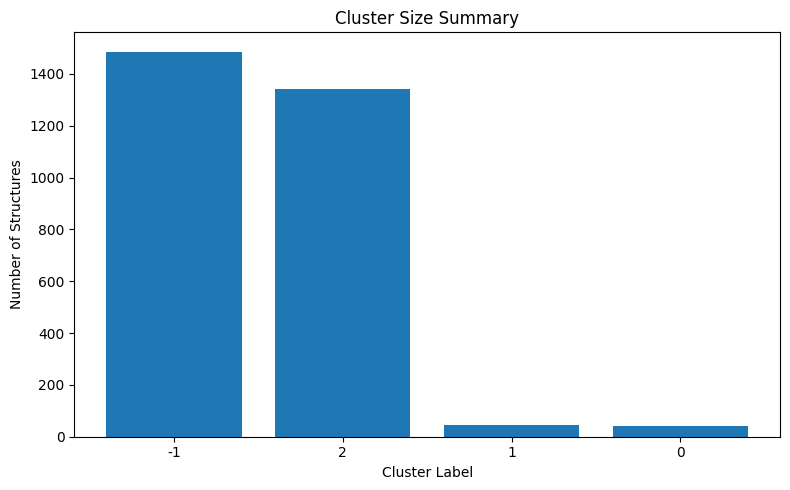

Saved: D:\masters_project\outputs\similarity_search\validation\figures\cluster_size_summary.png


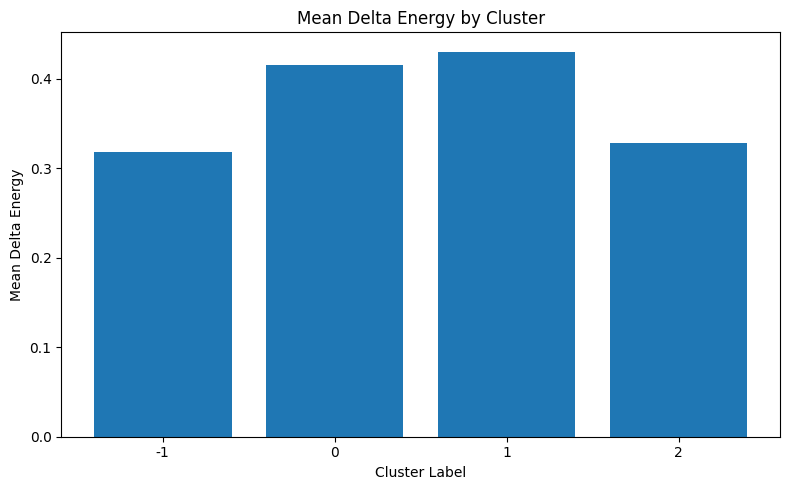

Saved: D:\masters_project\outputs\similarity_search\validation\figures\mean_delta_energy_by_cluster.png
Skipping UMAP plot for L100_D2.4_U220: umap_1/umap_2 not found.
Skipping UMAP plot for L0_D0_U200: umap_1/umap_2 not found.
Skipping UMAP plot for L160_D6_U120: umap_1/umap_2 not found.
Skipping UMAP plot for L260_D0_U280: umap_1/umap_2 not found.
Skipping UMAP plot for L120_D6_U280: umap_1/umap_2 not found.
Skipping UMAP plot for L240_D0_U260: umap_1/umap_2 not found.
Skipping UMAP plot for L340_D1.2_U220: umap_1/umap_2 not found.
Skipping PCA plot for L100_D2.4_U220: pca_1/pca_2 not found.
Skipping PCA plot for L0_D0_U200: pca_1/pca_2 not found.
Skipping PCA plot for L160_D6_U120: pca_1/pca_2 not found.
Skipping PCA plot for L260_D0_U280: pca_1/pca_2 not found.
Skipping PCA plot for L120_D6_U280: pca_1/pca_2 not found.
Skipping PCA plot for L240_D0_U260: pca_1/pca_2 not found.
Skipping PCA plot for L340_D1.2_U220: pca_1/pca_2 not found.


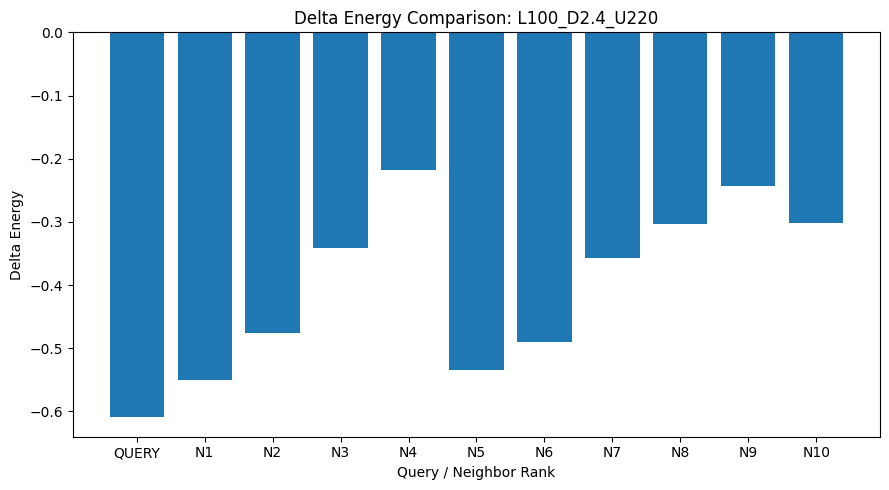

Saved: D:\masters_project\outputs\similarity_search\validation\figures\delta_energy_neighbors_L100_D2.4_U220.png


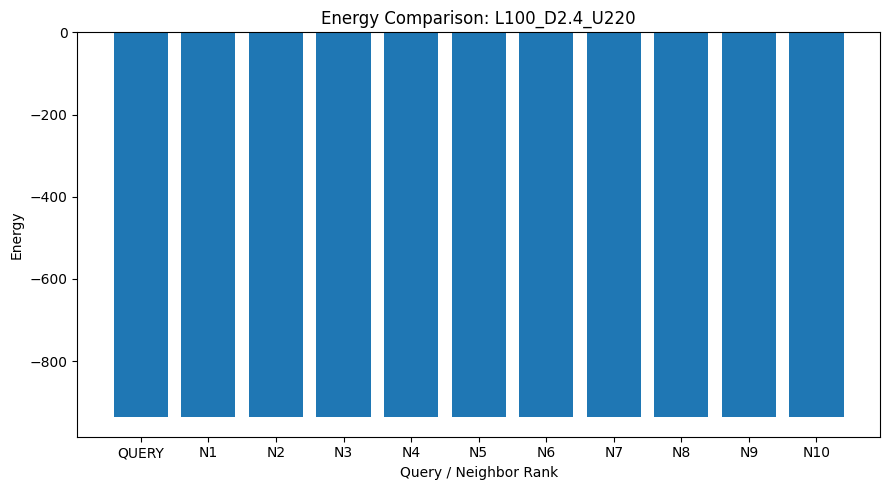

Saved: D:\masters_project\outputs\similarity_search\validation\figures\energy_neighbors_L100_D2.4_U220.png


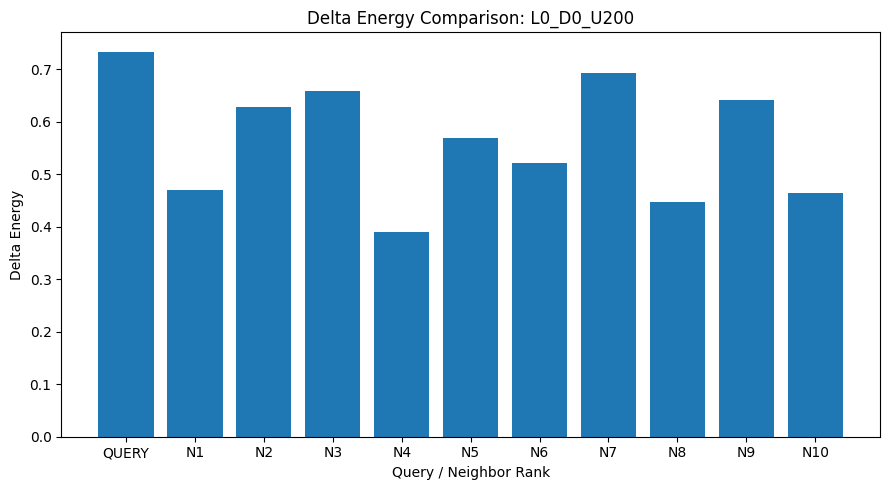

Saved: D:\masters_project\outputs\similarity_search\validation\figures\delta_energy_neighbors_L0_D0_U200.png


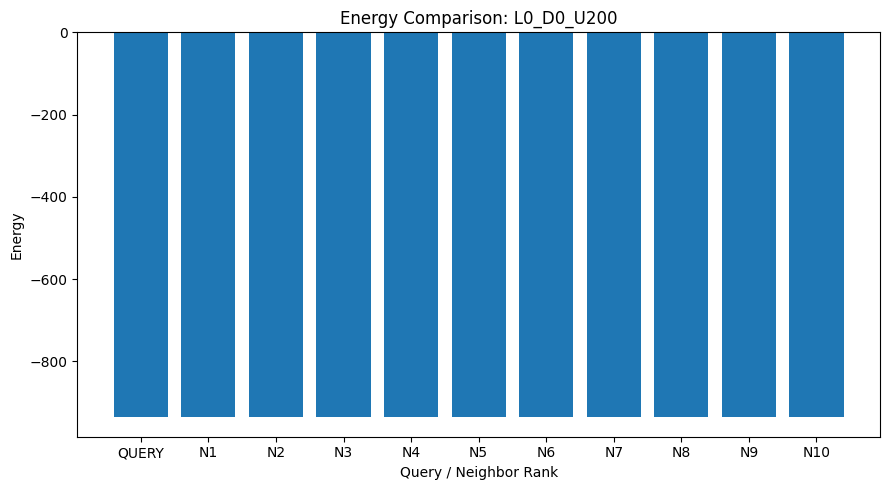

Saved: D:\masters_project\outputs\similarity_search\validation\figures\energy_neighbors_L0_D0_U200.png


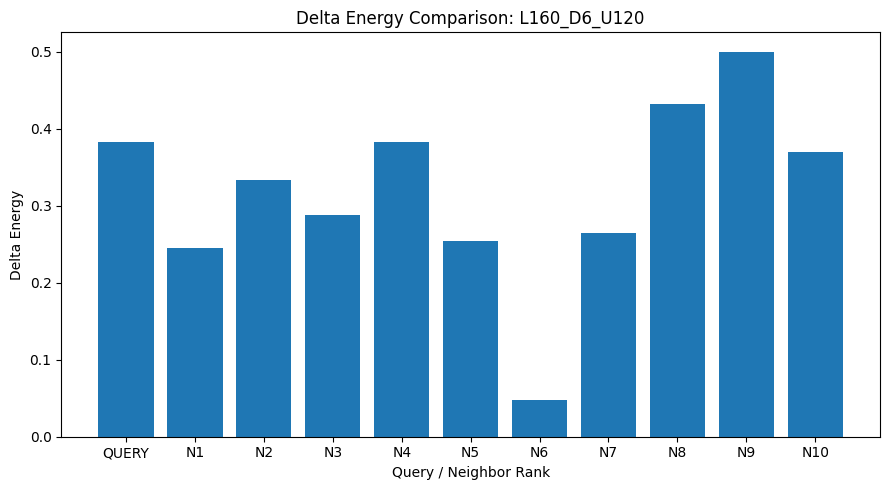

Saved: D:\masters_project\outputs\similarity_search\validation\figures\delta_energy_neighbors_L160_D6_U120.png


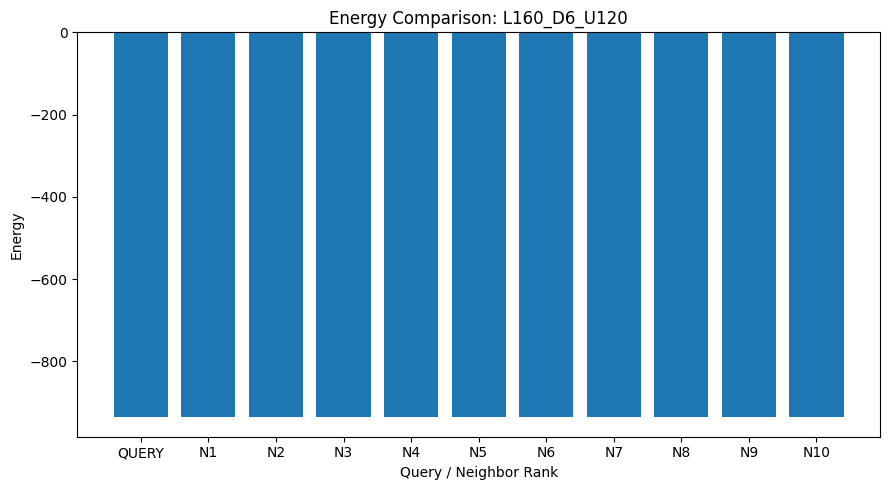

Saved: D:\masters_project\outputs\similarity_search\validation\figures\energy_neighbors_L160_D6_U120.png


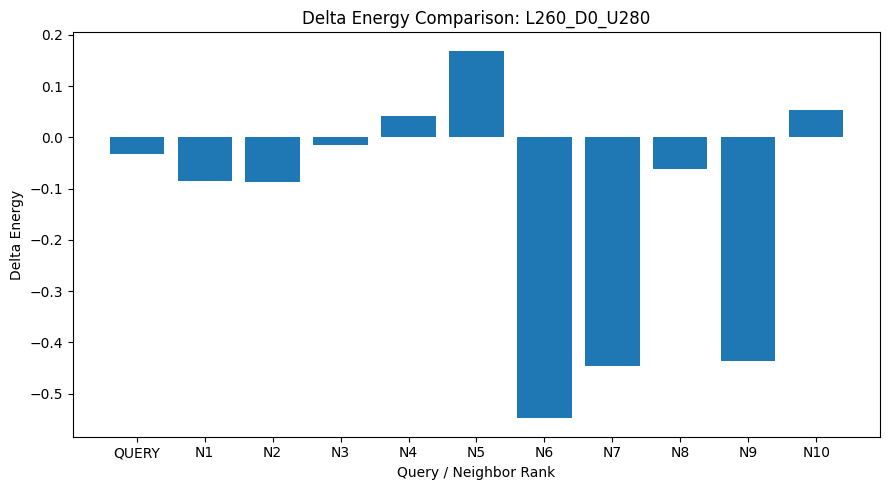

Saved: D:\masters_project\outputs\similarity_search\validation\figures\delta_energy_neighbors_L260_D0_U280.png


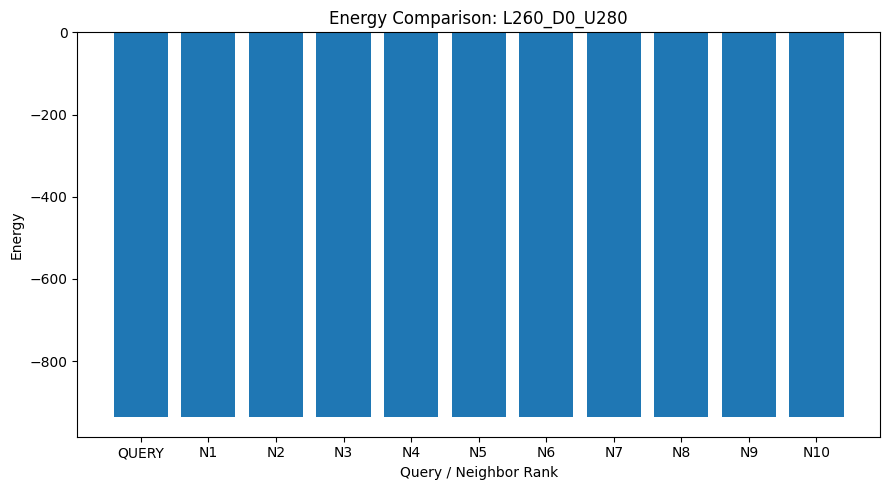

Saved: D:\masters_project\outputs\similarity_search\validation\figures\energy_neighbors_L260_D0_U280.png


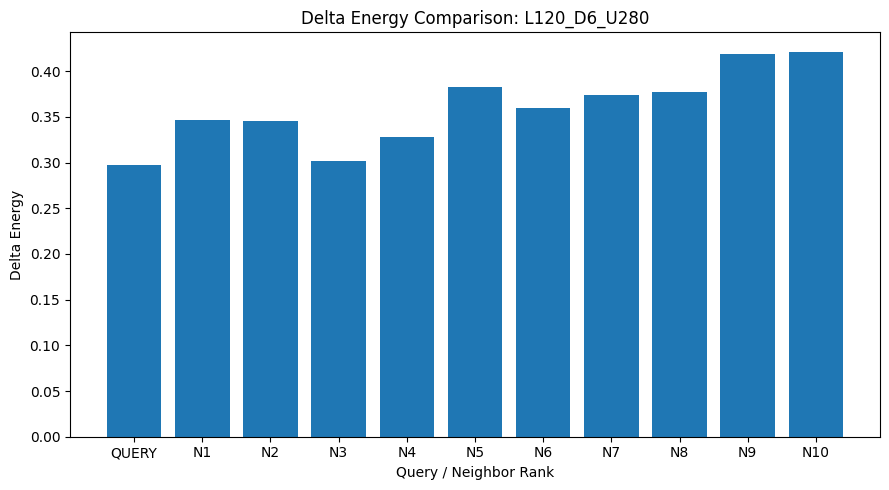

Saved: D:\masters_project\outputs\similarity_search\validation\figures\delta_energy_neighbors_L120_D6_U280.png


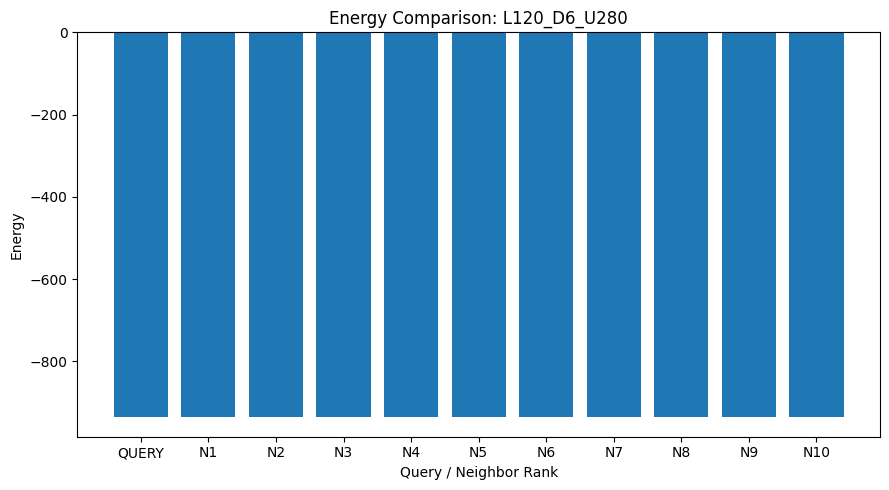

Saved: D:\masters_project\outputs\similarity_search\validation\figures\energy_neighbors_L120_D6_U280.png


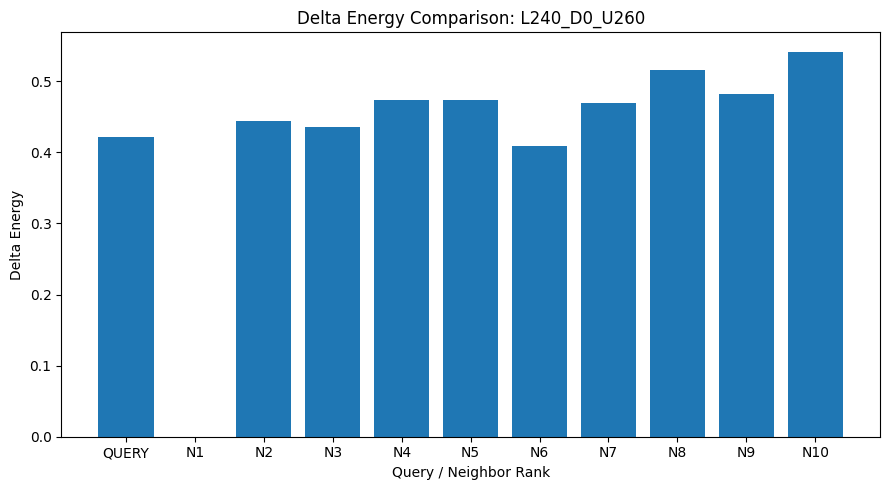

Saved: D:\masters_project\outputs\similarity_search\validation\figures\delta_energy_neighbors_L240_D0_U260.png


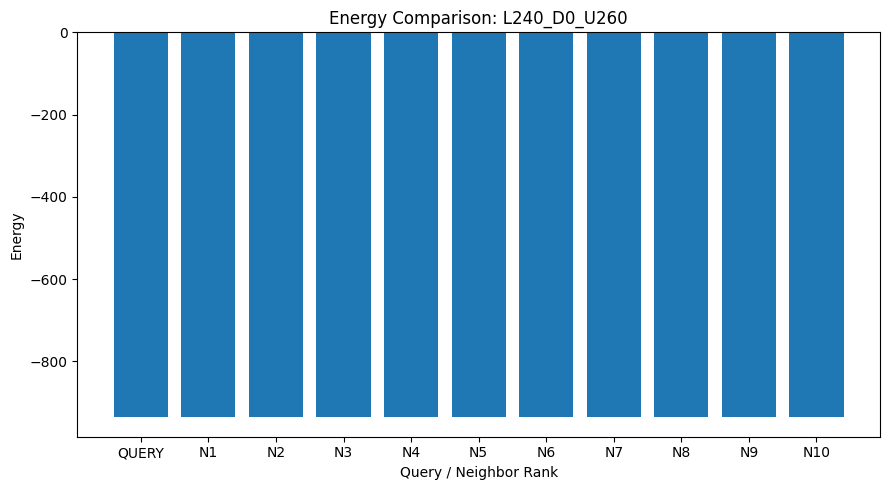

Saved: D:\masters_project\outputs\similarity_search\validation\figures\energy_neighbors_L240_D0_U260.png


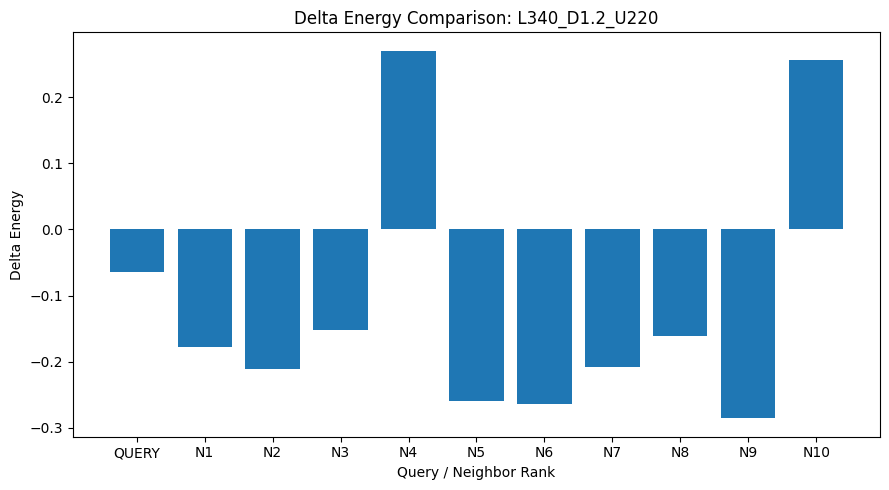

Saved: D:\masters_project\outputs\similarity_search\validation\figures\delta_energy_neighbors_L340_D1.2_U220.png


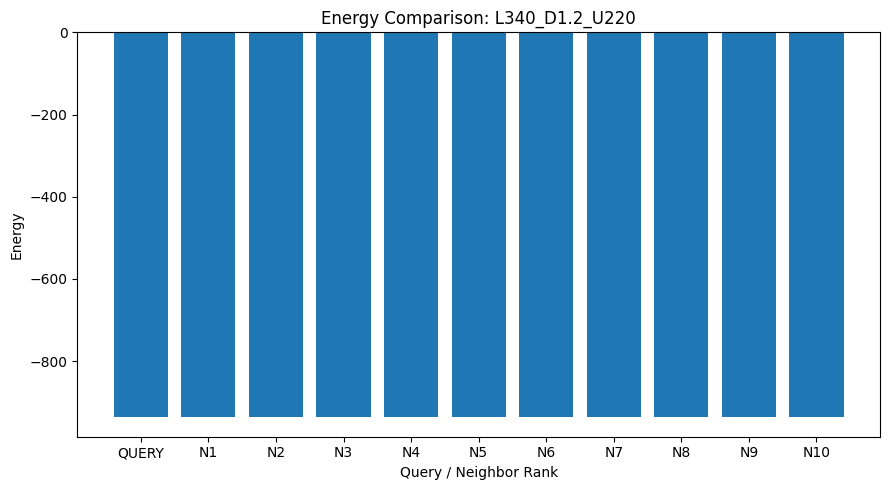

Saved: D:\masters_project\outputs\similarity_search\validation\figures\energy_neighbors_L340_D1.2_U220.png

Top-1 neighbor consistency:
  query_structure_id  query_cluster_label top1_neighbor_structure_id  \
0     L100_D2.4_U220                   -1             L100_D1.2_U220   
1         L0_D0_U200                    2               L0_D7.2_U200   
2       L160_D6_U120                    2             L160_D9.6_U120   
3       L260_D0_U280                   -1             L280_D1.2_U280   
4       L120_D6_U280                    0             L120_D7.2_U280   
5       L240_D0_U260                    1             L240_D8.4_U260   
6     L340_D1.2_U220                    2             L340_D2.4_U220   

   top1_neighbor_cluster_label  top1_same_cluster  top1_score  \
0                           -1               True    0.999674   
1                            2               True    0.968853   
2                           -1              False    0.985951   
3                          

In [2]:
# ============================================================
# Phase H Validation Add-On
# Task 38 — Compare structural neighbors
# ============================================================

import matplotlib.pyplot as plt


# ============================================================
# 1. Extra folders for validation outputs
# ============================================================

VALIDATION_DIR = SIMILARITY_DIR / "validation"
VALIDATION_FIG_DIR = VALIDATION_DIR / "figures"

VALIDATION_DIR.mkdir(parents=True, exist_ok=True)
VALIDATION_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("VALIDATION_DIR:", VALIDATION_DIR)
print("VALIDATION_FIG_DIR:", VALIDATION_FIG_DIR)


# ============================================================
# 2. Basic checks for plotting columns
# ============================================================

has_umap = all(col in retrieval_df.columns for col in ["umap_1", "umap_2"])
has_pca = all(col in retrieval_df.columns for col in ["pca_1", "pca_2"])
has_tsne = all(col in retrieval_df.columns for col in ["tsne_1", "tsne_2"])

print("has_umap:", has_umap)
print("has_pca:", has_pca)
print("has_tsne:", has_tsne)


# ============================================================
# 3. Cluster size summary
# ============================================================

cluster_size_summary = (
    retrieval_df.groupby("cluster_label")
    .size()
    .reset_index(name="structure_count")
    .sort_values("structure_count", ascending=False)
    .reset_index(drop=True)
)

cluster_size_summary["percent_of_dataset"] = (
    cluster_size_summary["structure_count"] / len(retrieval_df) * 100
)

cluster_size_summary_path = VALIDATION_DIR / "cluster_size_summary.csv"
cluster_size_summary.to_csv(cluster_size_summary_path, index=False)

print("\nCluster size summary:")
print(cluster_size_summary)
print("Saved:", cluster_size_summary_path)


# ============================================================
# 4. Motif energy summary
# ============================================================

motif_energy_summary = (
    retrieval_df.groupby("cluster_label")
    .agg(
        structure_count=("structure_id", "count"),
        min_energy=("energy", "min"),
        mean_energy=("energy", "mean"),
        max_energy=("energy", "max"),
        min_delta_energy=("delta_energy", "min"),
        mean_delta_energy=("delta_energy", "mean"),
        max_delta_energy=("delta_energy", "max"),
    )
    .reset_index()
    .sort_values("cluster_label")
    .reset_index(drop=True)
)

motif_energy_summary_path = VALIDATION_DIR / "motif_energy_summary.csv"
motif_energy_summary.to_csv(motif_energy_summary_path, index=False)

print("\nMotif energy summary:")
print(motif_energy_summary)
print("Saved:", motif_energy_summary_path)


# ============================================================
# 5. Query summary helper
# ============================================================

def build_query_validation_summary(query_ids, metric_df, retrieval_source, k=10):
    rows = []

    for qid in query_ids:
        query_meta = get_structure_metadata(qid, retrieval_source)
        neighbors = compare_query_and_neighbors(qid, metric_df, retrieval_source, k=k).copy()

        row = {
            "query_structure_id": qid,
            "query_cluster_label": query_meta["cluster_label"],
            "query_energy": query_meta["energy"],
            "query_delta_energy": query_meta["delta_energy"],
            "query_lower_rotation": query_meta["lower_rotation"],
            "query_displacement": query_meta["displacement"],
            "query_upper_rotation": query_meta["upper_rotation"],
            "top_k": k,
            "same_cluster_count": int(neighbors["same_cluster"].sum()),
            "same_cluster_fraction": float(neighbors["same_cluster"].mean()),
            "mean_neighbor_score": float(neighbors["score"].mean()),
            "min_neighbor_score": float(neighbors["score"].min()),
            "max_neighbor_score": float(neighbors["score"].max()),
            "mean_neighbor_energy": float(neighbors["energy"].mean()),
            "mean_neighbor_delta_energy": float(neighbors["delta_energy"].mean()),
            "mean_abs_energy_difference": float(neighbors["energy_difference"].abs().mean()),
            "mean_abs_delta_energy_difference": float(neighbors["delta_energy_difference"].abs().mean()),
            "mean_abs_lower_rotation_difference": float(neighbors["lower_rotation_difference"].abs().mean()),
            "mean_abs_displacement_difference": float(neighbors["displacement_difference"].abs().mean()),
            "mean_abs_upper_rotation_difference": float(neighbors["upper_rotation_difference"].abs().mean()),
        }

        rows.append(row)

    return pd.DataFrame(rows)


# ============================================================
# 6. Select a broader validation query set
# ============================================================

validation_query_ids = []

# lowest-energy overall
validation_query_ids.append(
    retrieval_df.sort_values("delta_energy", ascending=True).iloc[0]["structure_id"]
)

# highest-energy overall
validation_query_ids.append(
    retrieval_df.sort_values("delta_energy", ascending=False).iloc[0]["structure_id"]
)

# median-energy overall
validation_query_ids.append(
    retrieval_df.sort_values("delta_energy", ascending=True).iloc[len(retrieval_df) // 2]["structure_id"]
)

# one centroid-nearest representative from each cluster
for cl in sorted(retrieval_df["cluster_label"].dropna().unique()):
    rep_rows = motif_representatives[
        (motif_representatives["cluster_label"] == cl) &
        (motif_representatives["representative_type"] == "centroid_nearest")
    ]
    if not rep_rows.empty:
        validation_query_ids.append(rep_rows.iloc[0]["structure_id"])

validation_query_ids = list(dict.fromkeys(validation_query_ids))

print("\nValidation query IDs:")
print(validation_query_ids)


# ============================================================
# 7. Build query validation summary tables
# ============================================================

query_validation_cosine = build_query_validation_summary(
    validation_query_ids,
    neighbor_cosine,
    retrieval_df,
    k=10,
)

query_validation_euclid = build_query_validation_summary(
    validation_query_ids,
    neighbor_euclid,
    retrieval_df,
    k=10,
)

query_validation_cosine_path = VALIDATION_DIR / "query_validation_summary_cosine.csv"
query_validation_euclid_path = VALIDATION_DIR / "query_validation_summary_euclidean.csv"

query_validation_cosine.to_csv(query_validation_cosine_path, index=False)
query_validation_euclid.to_csv(query_validation_euclid_path, index=False)

print("\nCosine query validation summary:")
print(query_validation_cosine)

print("\nEuclidean query validation summary:")
print(query_validation_euclid)

print("Saved:", query_validation_cosine_path)
print("Saved:", query_validation_euclid_path)


# ============================================================
# 8. Save expanded query comparison tables
# ============================================================

expanded_query_tables = []

for qid in validation_query_ids:
    q_df = compare_query_and_neighbors(qid, neighbor_cosine, retrieval_df, k=10).copy()
    expanded_query_tables.append(q_df)

    safe_qid = str(qid).replace("/", "_").replace("\\", "_")
    q_path = VALIDATION_DIR / f"validation_neighbors_cosine_{safe_qid}.csv"
    q_df.to_csv(q_path, index=False)
    print("Saved:", q_path)

all_validation_neighbors_cosine = pd.concat(expanded_query_tables, ignore_index=True)
all_validation_neighbors_cosine_path = VALIDATION_DIR / "all_validation_neighbors_cosine.csv"
all_validation_neighbors_cosine.to_csv(all_validation_neighbors_cosine_path, index=False)

print("Saved:", all_validation_neighbors_cosine_path)


# ============================================================
# 9. Same-cluster retrieval by cluster summary
# ============================================================

same_cluster_by_query_cluster = (
    query_validation_cosine.groupby("query_cluster_label")
    .agg(
        num_queries=("query_structure_id", "count"),
        mean_same_cluster_count=("same_cluster_count", "mean"),
        mean_same_cluster_fraction=("same_cluster_fraction", "mean"),
        mean_abs_delta_energy_difference=("mean_abs_delta_energy_difference", "mean"),
        mean_abs_upper_rotation_difference=("mean_abs_upper_rotation_difference", "mean"),
        mean_abs_displacement_difference=("mean_abs_displacement_difference", "mean"),
    )
    .reset_index()
    .sort_values("query_cluster_label")
    .reset_index(drop=True)
)

same_cluster_by_query_cluster_path = VALIDATION_DIR / "same_cluster_summary_by_query_cluster.csv"
same_cluster_by_query_cluster.to_csv(same_cluster_by_query_cluster_path, index=False)

print("\nSame-cluster retrieval summary by query cluster:")
print(same_cluster_by_query_cluster)
print("Saved:", same_cluster_by_query_cluster_path)


# ============================================================
# 10. Plot cluster size bar chart
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(cluster_size_summary["cluster_label"].astype(str), cluster_size_summary["structure_count"])
plt.title("Cluster Size Summary")
plt.xlabel("Cluster Label")
plt.ylabel("Number of Structures")
plt.tight_layout()

cluster_size_fig_path = VALIDATION_FIG_DIR / "cluster_size_summary.png"
plt.savefig(cluster_size_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", cluster_size_fig_path)


# ============================================================
# 11. Plot motif mean delta energy
# ============================================================

motif_energy_plot_df = motif_energy_summary.sort_values("cluster_label").copy()

plt.figure(figsize=(8, 5))
plt.bar(motif_energy_plot_df["cluster_label"].astype(str), motif_energy_plot_df["mean_delta_energy"])
plt.title("Mean Delta Energy by Cluster")
plt.xlabel("Cluster Label")
plt.ylabel("Mean Delta Energy")
plt.tight_layout()

motif_delta_fig_path = VALIDATION_FIG_DIR / "mean_delta_energy_by_cluster.png"
plt.savefig(motif_delta_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", motif_delta_fig_path)


# ============================================================
# 12. UMAP highlight plots for query + neighbors
# ============================================================

def plot_query_neighbors_umap(query_structure_id, metric_df, retrieval_source, k=10, save_dir=None):
    if not has_umap:
        print(f"Skipping UMAP plot for {query_structure_id}: umap_1/umap_2 not found.")
        return None

    query_meta = get_structure_metadata(query_structure_id, retrieval_source)
    neighbors = get_top_neighbors(query_structure_id, metric_df, k=k)

    neighbor_ids = neighbors["neighbor_structure_id"].tolist()

    base_df = retrieval_source.copy()
    query_df = base_df[base_df["structure_id"] == query_structure_id].copy()
    neighbor_df = base_df[base_df["structure_id"].isin(neighbor_ids)].copy()

    plt.figure(figsize=(8, 6))
    plt.scatter(base_df["umap_1"], base_df["umap_2"], s=12, alpha=0.25)
    plt.scatter(neighbor_df["umap_1"], neighbor_df["umap_2"], s=45, alpha=0.9)
    plt.scatter(query_df["umap_1"], query_df["umap_2"], s=140, marker="X")

    for _, row in neighbor_df.iterrows():
        plt.text(row["umap_1"], row["umap_2"], str(row["structure_id"]), fontsize=7)

    qrow = query_df.iloc[0]
    plt.text(qrow["umap_1"], qrow["umap_2"], f"QUERY: {query_structure_id}", fontsize=8)

    plt.title(f"UMAP Retrieval View: {query_structure_id} (cluster {query_meta['cluster_label']})")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.tight_layout()

    if save_dir is not None:
        safe_qid = str(query_structure_id).replace("/", "_").replace("\\", "_")
        out_path = save_dir / f"umap_neighbors_{safe_qid}.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", out_path)
        return out_path

    plt.show()
    return None


for qid in validation_query_ids:
    plot_query_neighbors_umap(qid, neighbor_cosine, retrieval_df, k=10, save_dir=VALIDATION_FIG_DIR)


# ============================================================
# 13. PCA highlight plots for query + neighbors
# ============================================================

def plot_query_neighbors_pca(query_structure_id, metric_df, retrieval_source, k=10, save_dir=None):
    if not has_pca:
        print(f"Skipping PCA plot for {query_structure_id}: pca_1/pca_2 not found.")
        return None

    query_meta = get_structure_metadata(query_structure_id, retrieval_source)
    neighbors = get_top_neighbors(query_structure_id, metric_df, k=k)

    neighbor_ids = neighbors["neighbor_structure_id"].tolist()

    base_df = retrieval_source.copy()
    query_df = base_df[base_df["structure_id"] == query_structure_id].copy()
    neighbor_df = base_df[base_df["structure_id"].isin(neighbor_ids)].copy()

    plt.figure(figsize=(8, 6))
    plt.scatter(base_df["pca_1"], base_df["pca_2"], s=12, alpha=0.25)
    plt.scatter(neighbor_df["pca_1"], neighbor_df["pca_2"], s=45, alpha=0.9)
    plt.scatter(query_df["pca_1"], query_df["pca_2"], s=140, marker="X")

    for _, row in neighbor_df.iterrows():
        plt.text(row["pca_1"], row["pca_2"], str(row["structure_id"]), fontsize=7)

    qrow = query_df.iloc[0]
    plt.text(qrow["pca_1"], qrow["pca_2"], f"QUERY: {query_structure_id}", fontsize=8)

    plt.title(f"PCA Retrieval View: {query_structure_id} (cluster {query_meta['cluster_label']})")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.tight_layout()

    if save_dir is not None:
        safe_qid = str(query_structure_id).replace("/", "_").replace("\\", "_")
        out_path = save_dir / f"pca_neighbors_{safe_qid}.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", out_path)
        return out_path

    plt.show()
    return None


for qid in validation_query_ids:
    plot_query_neighbors_pca(qid, neighbor_cosine, retrieval_df, k=10, save_dir=VALIDATION_FIG_DIR)


# ============================================================
# 14. Query-neighbor energy comparison plots
# ============================================================

def plot_query_neighbor_energy(query_structure_id, metric_df, retrieval_source, k=10, save_dir=None):
    query_meta = get_structure_metadata(query_structure_id, retrieval_source)
    neighbors = get_top_neighbors(query_structure_id, metric_df, k=k).copy()

    labels = ["QUERY"] + [f"N{r}" for r in neighbors["neighbor_rank"]]
    delta_vals = [query_meta["delta_energy"]] + neighbors["delta_energy"].tolist()
    energy_vals = [query_meta["energy"]] + neighbors["energy"].tolist()

    # delta energy plot
    plt.figure(figsize=(9, 5))
    plt.bar(labels, delta_vals)
    plt.title(f"Delta Energy Comparison: {query_structure_id}")
    plt.xlabel("Query / Neighbor Rank")
    plt.ylabel("Delta Energy")
    plt.tight_layout()

    if save_dir is not None:
        safe_qid = str(query_structure_id).replace("/", "_").replace("\\", "_")
        out_path_1 = save_dir / f"delta_energy_neighbors_{safe_qid}.png"
        plt.savefig(out_path_1, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", out_path_1)
    else:
        plt.show()
        out_path_1 = None

    # energy plot
    plt.figure(figsize=(9, 5))
    plt.bar(labels, energy_vals)
    plt.title(f"Energy Comparison: {query_structure_id}")
    plt.xlabel("Query / Neighbor Rank")
    plt.ylabel("Energy")
    plt.tight_layout()

    if save_dir is not None:
        safe_qid = str(query_structure_id).replace("/", "_").replace("\\", "_")
        out_path_2 = save_dir / f"energy_neighbors_{safe_qid}.png"
        plt.savefig(out_path_2, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", out_path_2)
    else:
        plt.show()
        out_path_2 = None

    return out_path_1, out_path_2


for qid in validation_query_ids:
    plot_query_neighbor_energy(qid, neighbor_cosine, retrieval_df, k=10, save_dir=VALIDATION_FIG_DIR)


# ============================================================
# 15. Save top-neighbor same-cluster flag table
# ============================================================

top1_consistency_rows = []

for qid in validation_query_ids:
    query_meta = get_structure_metadata(qid, retrieval_df)
    top1 = get_top_neighbors(qid, neighbor_cosine, k=1).iloc[0]

    top1_consistency_rows.append(
        {
            "query_structure_id": qid,
            "query_cluster_label": query_meta["cluster_label"],
            "top1_neighbor_structure_id": top1["neighbor_structure_id"],
            "top1_neighbor_cluster_label": top1["cluster_label"],
            "top1_same_cluster": bool(top1["cluster_label"] == query_meta["cluster_label"]),
            "top1_score": float(top1["score"]),
            "query_delta_energy": float(query_meta["delta_energy"]),
            "top1_delta_energy": float(top1["delta_energy"]),
            "top1_abs_delta_energy_difference": float(abs(top1["delta_energy"] - query_meta["delta_energy"])),
        }
    )

top1_consistency_df = pd.DataFrame(top1_consistency_rows)
top1_consistency_path = VALIDATION_DIR / "top1_neighbor_consistency.csv"
top1_consistency_df.to_csv(top1_consistency_path, index=False)

print("\nTop-1 neighbor consistency:")
print(top1_consistency_df)
print("Saved:", top1_consistency_path)


# ============================================================
# 16. Global retrieval consistency estimate
# ============================================================

global_consistency_rows = []

sample_global_queries = retrieval_df["structure_id"].tolist()[::75]

for qid in sample_global_queries:
    query_meta = get_structure_metadata(qid, retrieval_df)
    neighbors = get_top_neighbors(qid, neighbor_cosine, k=10).copy()

    global_consistency_rows.append(
        {
            "query_structure_id": qid,
            "query_cluster_label": query_meta["cluster_label"],
            "same_cluster_fraction_top10": float((neighbors["cluster_label"] == query_meta["cluster_label"]).mean()),
            "mean_abs_delta_energy_difference_top10": float(np.mean(np.abs(neighbors["delta_energy"] - query_meta["delta_energy"]))),
        }
    )

global_consistency_df = pd.DataFrame(global_consistency_rows)

global_consistency_summary = {
    "num_sampled_queries": int(len(global_consistency_df)),
    "mean_same_cluster_fraction_top10": float(global_consistency_df["same_cluster_fraction_top10"].mean()),
    "median_same_cluster_fraction_top10": float(global_consistency_df["same_cluster_fraction_top10"].median()),
    "mean_abs_delta_energy_difference_top10": float(global_consistency_df["mean_abs_delta_energy_difference_top10"].mean()),
    "median_abs_delta_energy_difference_top10": float(global_consistency_df["mean_abs_delta_energy_difference_top10"].median()),
}

global_consistency_df_path = VALIDATION_DIR / "global_retrieval_consistency_sample.csv"
global_consistency_summary_path = VALIDATION_DIR / "global_retrieval_consistency_summary.json"

global_consistency_df.to_csv(global_consistency_df_path, index=False)

with open(global_consistency_summary_path, "w", encoding="utf-8") as f:
    json.dump(global_consistency_summary, f, indent=2)

print("\nGlobal retrieval consistency sample:")
print(global_consistency_df.head())

print("\nGlobal retrieval consistency summary:")
print(json.dumps(global_consistency_summary, indent=2))

print("Saved:", global_consistency_df_path)
print("Saved:", global_consistency_summary_path)


# ============================================================
# 17. Final validation summary
# ============================================================

phase_h_validation_summary = {
    "validation_query_count": int(len(validation_query_ids)),
    "cluster_labels": sorted([int(x) for x in retrieval_df["cluster_label"].dropna().unique().tolist()]),
    "cluster_size_summary_file": str(cluster_size_summary_path),
    "motif_energy_summary_file": str(motif_energy_summary_path),
    "query_validation_cosine_file": str(query_validation_cosine_path),
    "query_validation_euclidean_file": str(query_validation_euclid_path),
    "same_cluster_summary_file": str(same_cluster_by_query_cluster_path),
    "top1_consistency_file": str(top1_consistency_path),
    "global_retrieval_consistency_sample_file": str(global_consistency_df_path),
    "global_retrieval_consistency_summary_file": str(global_consistency_summary_path),
}

phase_h_validation_summary_path = VALIDATION_DIR / "phase_h_validation_summary.json"
with open(phase_h_validation_summary_path, "w", encoding="utf-8") as f:
    json.dump(phase_h_validation_summary, f, indent=2)

print("\nSaved:", phase_h_validation_summary_path)
print(json.dumps(phase_h_validation_summary, indent=2))

print("\nPhase H validation add-on completed successfully.")
print("Validation outputs saved in:", VALIDATION_DIR)